In [1]:
import os, sys
# Run from project root so all relative paths and imports work
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

In [2]:
import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Utilities import plot_das_data

/home/chao/miniconda3/envs/au_sable/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# Inspect labels.csv produced by: python prepare_data.py
df = pd.read_csv("data/labels.csv")
print(f"{len(df)} samples | columns: {list(df.columns)}")
print(f"vehicle_type counts:\n{df['vehicle_type'].value_counts()}")
df.head(10)

113 samples | columns: ['sample_id', 'data_path', 'count', 'start_frame', 'end_frame', 'vehicle_type', 'signal_rects']
vehicle_type counts:
vehicle_type
mixed         49
background    39
suv           14
van            6
truck          4
sedan          1
Name: count, dtype: int64


,sample_id,data_path,count,start_frame,end_frame,vehicle_type,signal_rects
0,0,data/raw/sample_000000.npy,4,1873,2023,mixed,"[[1873, 1900], [1879, 1909], [1929, 1959], [19..."
1,1,data/raw/sample_000001.npy,4,1902,2053,mixed,"[[1902, 1909], [1929, 1959], [1953, 1983]]"
2,2,data/raw/sample_000002.npy,3,1932,2083,mixed,"[[1932, 1959], [1953, 1983], [2060, 2083]]"
3,3,data/raw/sample_000003.npy,3,1962,2113,mixed,"[[1962, 1983], [2060, 2090]]"
4,4,data/raw/sample_000004.npy,2,1992,2143,mixed,"[[2060, 2090]]"
5,5,data/raw/sample_000005.npy,1,2022,2173,suv,"[[2060, 2090]]"
6,6,data/raw/sample_000006.npy,1,2052,2203,suv,"[[2060, 2090]]"
7,7,data/raw/sample_000007.npy,1,2082,2233,suv,"[[2082, 2090]]"
8,8,data/raw/sample_000008.npy,1,2112,2263,suv,"[[2259, 2263]]"
9,9,data/raw/sample_000009.npy,1,2142,2293,suv,"[[2259, 2289]]"


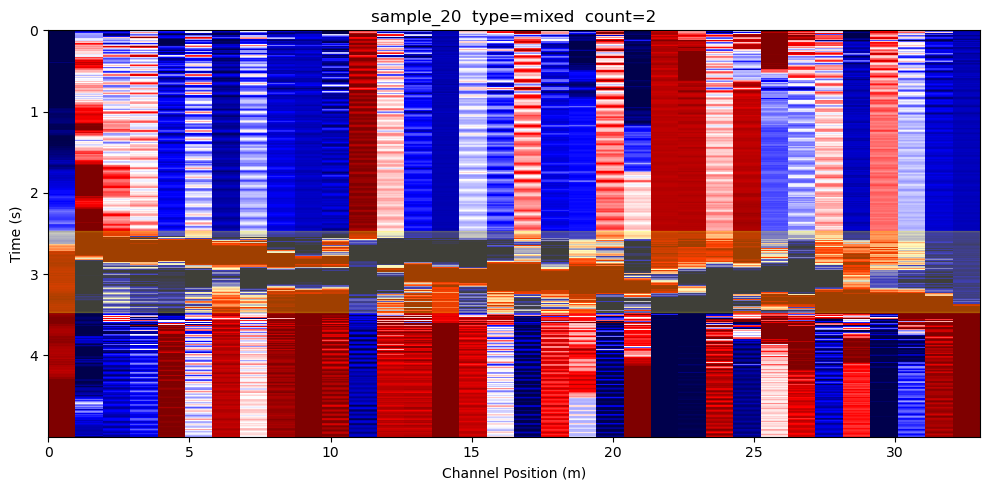

signal_rects (global frames): [[2546, 2576]]


In [8]:
# Visualize a sample window with signal_rects overlaid
cfg = yaml.safe_load(open("configs/data_prep.yaml"))
fs_das = cfg["fs_das"]
fps_video = cfg["fps_video"]

row = df[df["count"] > 0].iloc[20]
x = np.load(row["data_path"])
rects = json.loads(row["signal_rects"])

fig, ax = plot_das_data(
    x,
    channels=np.arange(x.shape[0]),
    dx=cfg.get("dx", 1.0),
    dt=1 / fs_das,
    show=False,
    title=f"sample_{row['sample_id']}  type={row['vehicle_type']}  count={row['count']}",
)

# Shade signal rects (time axis = vertical)
for rect_s, rect_e in rects:
    t_s = (rect_s - row["start_frame"]) / fps_video
    t_e = (rect_e - row["start_frame"]) / fps_video
    ax.axhspan(t_s, t_e, alpha=0.25, color="yellow")

plt.tight_layout()
plt.show()
print(f"signal_rects (global frames): {rects}")